# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================

In [11]:
import pyodbc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ==========================================
# 2. LOAD DATA FROM SQL SERVER
# ==========================================

In [12]:
conn = pyodbc.connect(
    'DRIVER={SQL Server};'
    'SERVER=SAMANEH;'
    'DATABASE=BankMarketingDB;'
    'Trusted_Connection=yes;'
)
query = """
SELECT 
    age_int AS age,
    job,
    marital,
    education,
    [default],
    balance_int AS balance,
    housing,
    loan,
    contact,
    day_int AS day,
    month,
    duration_int AS duration,
    campaign_int AS campaign,
    pdays_int AS pdays,
    previous_int AS previous,
    poutcome,
    y
FROM [dbo].[bank-full]
"""

df = pd.read_sql(query, conn)
conn.close()

print(df.info())

print(df.head(10))

print(f"Total ROWS: {len(df):,}")
print(f"Total Columns: {len(df.columns)}")


C:\Users\hp\AppData\Local\Temp\ipykernel_34808\2544318966.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None
   age               job       marital      education  default  balance  \
0   58    ""managem

# ==========================================
# 3. EXPLORATORY DATA ANALYSIS (EDA) & STATISTICAL ANALYSIS
# ==========================================

In [13]:
num_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan',
            'contact', 'month', 'poutcome', 'y']

desc = df[num_cols].describe().T
desc['median'] = df[num_cols].median()
desc['skewness'] = df[num_cols].skew()
desc['kurtosis'] = df[num_cols].kurt()
desc['IQR'] = desc['75%'] - desc['25%']
print(desc[['mean','median','std','min','25%','50%','75%','max','IQR','skewness','kurtosis']])

for col in cat_cols:
    print(f"\n{col}:\n", df[col].value_counts(normalize=True).mul(100).round(1))

                 mean  median          std     min    25%    50%     75%  \
age         40.936210    39.0    10.618762    18.0   33.0   39.0    48.0   
balance   1362.272058   448.0  3044.765829 -8019.0   72.0  448.0  1428.0   
day         15.806419    16.0     8.322476     1.0    8.0   16.0    21.0   
duration   258.163080   180.0   257.527812     0.0  103.0  180.0   319.0   
campaign     2.763841     2.0     3.098021     1.0    1.0    2.0     3.0   
pdays       40.197828    -1.0   100.128746    -1.0   -1.0   -1.0    -1.0   
previous     0.580323     0.0     2.303441     0.0    0.0    0.0     0.0   

               max     IQR   skewness     kurtosis  
age           95.0    15.0   0.684818     0.319570  
balance   102127.0  1356.0   8.360308   140.751547  
day           31.0    13.0   0.093079    -1.059897  
duration    4918.0   216.0   3.144318    18.153915  
campaign      63.0     2.0   4.898650    39.249651  
pdays        871.0     0.0   2.615715     6.935195  
previous     275.0  

# Campaign Improvement Insights

## 1. Customer Targeting

* Customers with **higher account balances** exhibit a greater likelihood of subscribing to term deposits. Therefore, marketing efforts should prioritize high-balance customers to improve campaign effectiveness.

* Customers with **no outstanding housing or personal loans** (`housing = no`, `loan = no`) demonstrate higher positive response rates. This segment appears to be more financially flexible and receptive to deposit offers.

* Regarding occupation, **students and retired individuals** show stronger subscription rates compared to **blue-collar workers**, suggesting that occupation-based segmentation could improve targeting precision.

## 2. Call Strategy Optimization

* **Call duration** has the strongest positive association with successful outcomes. Longer conversations are correlated with a higher probability of subscription, indicating that agents should focus on engagement quality and customer interaction depth.

* A high number of campaign contacts (`campaign`) tends to negatively affect conversion rates. Excessive contact attempts may reduce customer responsiveness; therefore, outreach frequency should be optimized.

* Although **May records the highest call volume**, it does not necessarily yield the best conversion performance. Further experimentation across different months is recommended to identify more effective campaign timing.

## 3. Prior Contact History

* Customers with a **successful outcome in previous campaigns** (`poutcome = success`) are substantially more likely to respond positively again. Re-targeting this group should be considered a high-priority strategy.

* A large proportion of customers have **no prior contact history** (`pdays = -1`), highlighting an opportunity to establish a structured follow-up pipeline for long-term customer engagement.

## 4. Data and Modeling Considerations

* The target variable is **highly imbalanced**, with approximately **88.3% of observations labeled as “no”**. To improve predictive performance on the minority class (“yes”), techniques such as **class weighting**, **oversampling**, or **SMOTE** should be considered.

* Although **duration** is the strongest predictor of campaign success, it is only available **after the call has occurred**. Including this feature in real-time prediction systems may lead to **data leakage**, so it should be excluded from pre-contact predictive models.

## 5. Communication Channel Effectiveness

* **Cellular communication** outperforms traditional telephone contact in terms of positive response rates. Consequently, prioritizing mobile outreach may improve overall campaign efficiency.
itize mobile outreach

In [14]:
df_clean = df.copy()

In [15]:
print(df.isnull().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


## No missing values were detected in the dataset.

In [28]:
df_clean['y'] = (
    df_clean['y']
    .str.replace('"', '', regex=False)
    .str.strip()
    .str.lower()
)

In [29]:
print(df_clean['y'].unique())

['no' 'yes']


In [30]:
df_clean['y_binary'] = df_clean['y'].map({
    'no': 0,
    'yes': 1
})

In [32]:
print(df_clean[['y', 'y_binary']].head())

    y  y_binary
0  no         0
1  no         0
2  no         0
3  no         0
4  no         0


In [33]:
numeric_df = df_clean.select_dtypes(
    include=['int64', 'float64']
)

corr_matrix = numeric_df.corr()

print(
    corr_matrix['y_binary']
    .sort_values(ascending=False)
)

y_binary    1.000000
duration    0.394521
pdays       0.103621
previous    0.093236
balance     0.052838
age         0.025155
day        -0.028348
campaign   -0.073172
Name: y_binary, dtype: float64


### Correlation Analysis

A correlation analysis was conducted to examine the relationship between numerical variables and campaign subscription outcomes.

The results indicate that **call duration** has the strongest positive correlation with campaign success (`r = 0.39`), suggesting that longer customer interactions are associated with higher subscription likelihood. However, since this variable becomes available only after the call, it may introduce data leakage in predictive modeling.

Variables such as **account balance** (`r = 0.05`), **previous contacts** (`r = 0.09`), and **days since prior contact** (`r = 0.10`) show weak positive relationships with subscription outcomes.

In contrast, the number of campaign contacts (`campaign`) demonstrates a weak negative correlation (`r = -0.07`), implying that excessive contact attempts may reduce customer responsiveness.


In [34]:
from scipy.stats import chi2_contingency

cat_features = [
    'job',
    'marital',
    'education',
    'housing',
    'loan',
    'contact',
    'month',
    'poutcome'
]

for col in cat_features:

    table = pd.crosstab(
        df_clean[col],
        df_clean['y']
    )

    chi2, p, dof, expected = chi2_contingency(table)

    print(f'{col}: p-value = {p:.10f}')

job: p-value = 0.0000000000
marital: p-value = 0.0000000000
education: p-value = 0.0000000000
housing: p-value = 0.0000000000
loan: p-value = 0.0000000000
contact: p-value = 0.0000000000
month: p-value = 0.0000000000
poutcome: p-value = 0.0000000000


### Chi-Square Analysis

A Chi-Square test of independence was performed to examine the relationship between categorical variables and campaign subscription outcomes.

The results show statistically significant associations (`p < 0.05`) between subscription outcomes and all examined categorical features, including **job**, **marital status**, **education**, **housing loan**, **personal loan**, **contact type**, **month**, and **previous campaign outcome**.

These findings suggest that customer demographic characteristics, financial conditions, communication channels, and historical campaign performance all play meaningful roles in predicting subscription behavior.

Notably, **previous campaign outcome (`poutcome`)** and **contact type** appear to be particularly important factors for customer targeting strategies.


In [35]:
from scipy.stats import ttest_ind

num_features = [
    'age',
    'balance',
    'duration',
    'campaign',
    'pdays',
    'previous'
]

for col in num_features:

    yes_group = df_clean[
        df_clean['y'] == 'yes'
    ][col]

    no_group = df_clean[
        df_clean['y'] == 'no'
    ][col]

    t_stat, p_value = ttest_ind(
        yes_group,
        no_group,
        equal_var=False
    )

    print(
        f'{col}: '
        f't={t_stat:.3f}, '
        f'p={p_value:.10f}'
    )

age: t=4.318, p=0.0000159710
balance: t=9.934, p=0.0000000000
duration: t=57.514, p=0.0000000000
campaign: t=-22.801, p=0.0000000000
pdays: t=18.943, p=0.0000000000
previous: t=18.118, p=0.0000000000


### Independent T-Test Analysis

An independent t-test was conducted to compare numerical variables between customers who subscribed to the term deposit (`yes`) and those who did not (`no`).

The results revealed statistically significant differences (`p < 0.05`) across all examined numerical variables, including **age**, **balance**, **duration**, **campaign**, **pdays**, and **previous contacts**.

Among these variables, **call duration** showed the strongest difference between groups (`t = 57.51`), indicating that successful subscriptions are strongly associated with longer customer interactions.

Similarly, **account balance** exhibited a significant difference (`t = 9.93`), suggesting that customers with higher balances are more likely to subscribe.

Interestingly, **campaign frequency** demonstrated a negative relationship (`t = -22.80`), implying that excessive contact attempts may reduce campaign effectiveness.


# ==========================================
## 4-Visulization

# ==========================================

# Target Distribution

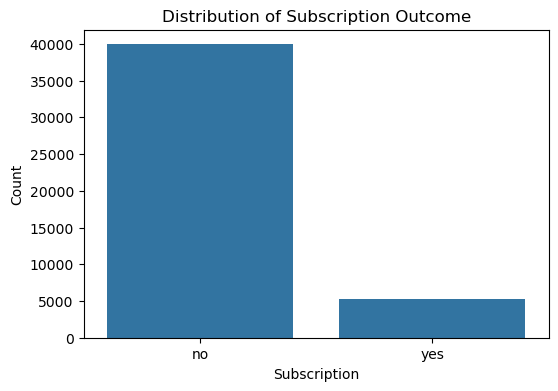

In [37]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='y',
    data=df_clean
)

plt.title('Distribution of Subscription Outcome')
plt.xlabel('Subscription')
plt.ylabel('Count')

plt.show()

# Most customers did not subscribe, indicating a highly imbalanced dataset.

## Age Distribution

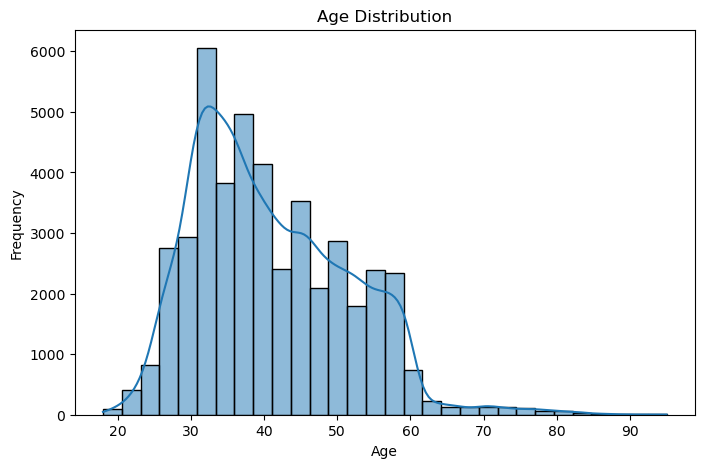

In [40]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_clean['age'],
    bins=30,
    kde=True
)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

## Most customers fall within middle-age groups.

## Balance Distribution + Outliers

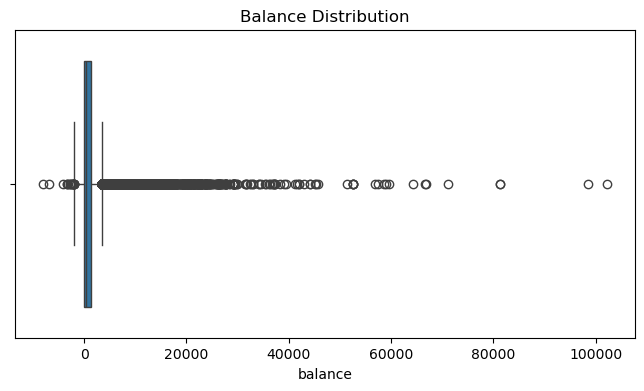

In [41]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df_clean['balance']
)

plt.title('Balance Distribution')

plt.show()

## Account balance contains substantial outliers and high variability.

## Job vs Subscription

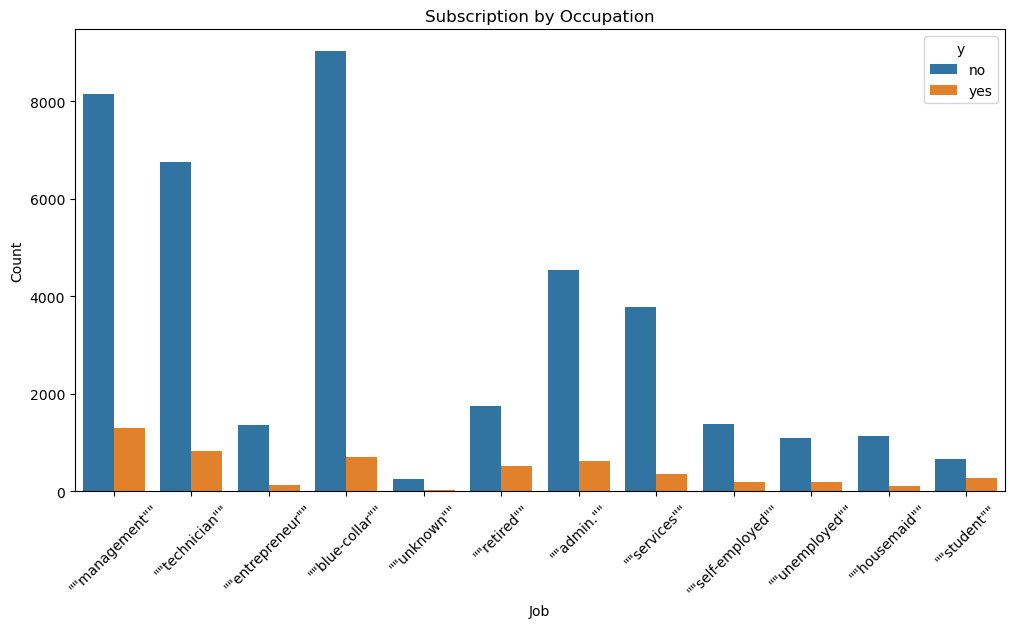

In [42]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='job',
    hue='y',
    data=df_clean
)

plt.xticks(rotation=45)

plt.title('Subscription by Occupation')
plt.xlabel('Job')
plt.ylabel('Count')

plt.show()

## Students and retired customers show higher response rates.

## Contact Type vs Subscription

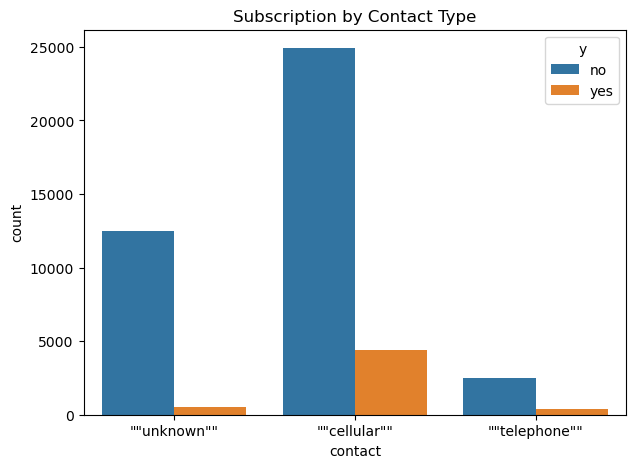

In [44]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='contact',
    hue='y',
    data=df_clean
)

plt.title('Subscription by Contact Type')

plt.show()

## Cellular contact appears more effective than telephone communication.

## Month vs Subscription

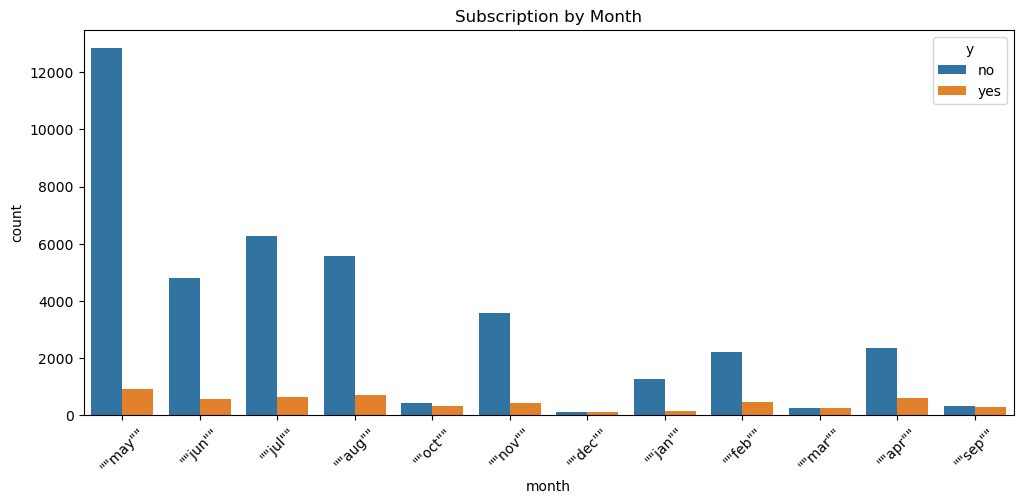

In [45]:
plt.figure(figsize=(12,5))

sns.countplot(
    x='month',
    hue='y',
    data=df_clean
)

plt.title('Subscription by Month')
plt.xticks(rotation=45)

plt.show()

## Call activity peaks in May, though conversion performance varies by month.

## Correlation Heatmap

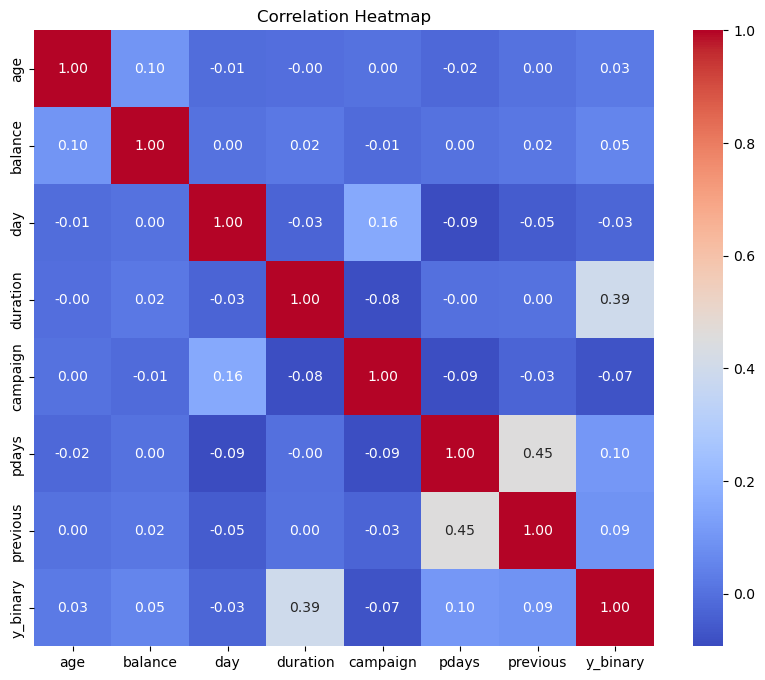

In [49]:
numeric_df = df_clean.select_dtypes(
    include=['int64', 'float64']
)

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')


plt.show()

# ==========================================
## 5. MACHINE LEARNING MODELING
# ==========================================

## Duration has the strongest positive relationship with subscription outcome.

## 5.1 DATA PREPARATION

In [55]:
df_model = df_clean.copy()

print(df_model.shape)
df_model.head()

(45211, 18)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,y_binary
0,58,"""""management""""","""""married""""","""""tertiary""""","""""no""""",2143,"""""yes""""","""""no""""","""""unknown""""",5,"""""may""""",261,1,-1,0,"""""unknown""""",no,0
1,44,"""""technician""""","""""single""""","""""secondary""""","""""no""""",29,"""""yes""""","""""no""""","""""unknown""""",5,"""""may""""",151,1,-1,0,"""""unknown""""",no,0
2,33,"""""entrepreneur""""","""""married""""","""""secondary""""","""""no""""",2,"""""yes""""","""""yes""""","""""unknown""""",5,"""""may""""",76,1,-1,0,"""""unknown""""",no,0
3,47,"""""blue-collar""""","""""married""""","""""unknown""""","""""no""""",1506,"""""yes""""","""""no""""","""""unknown""""",5,"""""may""""",92,1,-1,0,"""""unknown""""",no,0
4,33,"""""unknown""""","""""single""""","""""unknown""""","""""no""""",1,"""""no""""","""""no""""","""""unknown""""",5,"""""may""""",198,1,-1,0,"""""unknown""""",no,0


In [56]:
# remove leakage feature
df_model = df_model.drop(
    columns=['duration']
)

print(df_model.columns)

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous',
       'poutcome', 'y', 'y_binary'],
      dtype='object')


In [57]:
# convert target to binary
df_model['y'] = df_model['y'].map({
    'no': 0,
    'yes': 1
})

print(df_model['y'].value_counts())

y
0    39922
1     5289
Name: count, dtype: int64


In [58]:
print(df_model.info())

print(df_model.head())

print(df_model.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  campaign   45211 non-null  int64 
 12  pdays      45211 non-null  int64 
 13  previous   45211 non-null  int64 
 14  poutcome   45211 non-null  object
 15  y          45211 non-null  int64 
 16  y_binary   45211 non-null  int64 
dtypes: int64(8), object(9)
memory usage: 5.9+ MB
None
   age               job      marital      education default  balance  \
0   58    ""management

In [59]:
# CLEAN CATEGORICAL COLUMNS

cat_cols = [
    'job',
    'marital',
    'education',
    'default',
    'housing',
    'loan',
    'contact',
    'month',
    'poutcome'
]

for col in cat_cols:
    df_model[col] = (
        df_model[col]
        .str.replace('"', '', regex=False)
        .str.strip()
    )

# remove duplicate target column
df_model.drop(
    columns=['y_binary'],
    inplace=True
)

print(df_model.head())

print(df_model.info())

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  campaign  pdays  previous poutcome  y  
0  unknown    5   may         1     -1         0  unknown  0  
1  unknown    5   may         1     -1         0  unknown  0  
2  unknown    5   may         1     -1         0  unknown  0  
3  unknown    5   may         1     -1         0  unknown  0  
4  unknown    5   may         1     -1         0  unknown  0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     -------------

In [60]:
# FEATURE SELECTION

X = df_model.drop(columns=['y'])

y = df_model['y']

print("X shape:", X.shape)
print("y shape:", y.shape)

print(X.head())

X shape: (45211, 15)
y shape: (45211,)
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  campaign  pdays  previous poutcome  
0  unknown    5   may         1     -1         0  unknown  
1  unknown    5   may         1     -1         0  unknown  
2  unknown    5   may         1     -1         0  unknown  
3  unknown    5   may         1     -1         0  unknown  
4  unknown    5   may         1     -1         0  unknown  


In [61]:
# DEFINE FEATURE TYPES

num_features = [
    'age',
    'balance',
    'day',
    'campaign',
    'pdays',
    'previous'
]

cat_features = [
    'job',
    'marital',
    'education',
    'default',
    'housing',
    'loan',
    'contact',
    'month',
    'poutcome'
]

print("Numerical Features:")
print(num_features)

print("\nCategorical Features:")
print(cat_features)

Numerical Features:
['age', 'balance', 'day', 'campaign', 'pdays', 'previous']

Categorical Features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [62]:
# ==========================================
# MACHINE LEARNING IMPORTS
# ==========================================

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.compose import (
    ColumnTransformer
)

from sklearn.pipeline import Pipeline

In [63]:
# PREPROCESSING PIPELINE

# numerical preprocessing
numeric_transformer = Pipeline(
    steps=[
        ('scaler', StandardScaler())
    ]
)

# categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        (
            'encoder',
            OneHotEncoder(
                handle_unknown='ignore'
            )
        )
    ]
)

# combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            numeric_transformer,
            num_features
        ),
        (
            'cat',
            categorical_transformer,
            cat_features
        )
    ]
)

print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['age', 'balance', 'day', 'campaign', 'pdays',
                                  'previous']),
                                ('cat',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['job', 'marital', 'education', 'default',
                                  'housing', 'loan', 'contact', 'month',
                                  'poutcome'])])


In [64]:
# TRAIN / TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\ny_train distribution:")
print(y_train.value_counts(normalize=True))

print("\ny_test distribution:")
print(y_test.value_counts(normalize=True))

X_train: (36168, 15)
X_test : (9043, 15)

y_train distribution:
y
0    0.883018
1    0.116982
Name: proportion, dtype: float64

y_test distribution:
y
0    0.883003
1    0.116997
Name: proportion, dtype: float64


In [65]:
# MODELING IMPORTS

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [66]:
# LOGISTIC REGRESSION MODEL

model_lr = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'classifier',
            LogisticRegression(
                class_weight='balanced',
                random_state=42,
                max_iter=1000
            )
        )
    ]
)

# train model
model_lr.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [67]:
# MODEL PREDICTION

# class prediction
y_pred = model_lr.predict(X_test)

# probability prediction
y_prob = model_lr.predict_proba(X_test)[:, 1]

print(y_pred[:10])
print(y_prob[:10])

[0 0 0 0 1 0 0 1 0 0]
[0.10720581 0.16390665 0.21231741 0.12968103 0.53497575 0.28847555
 0.37365682 0.97193644 0.45616734 0.43409987]


In [68]:
# MODEL EVALUATION

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.7548
Precision: 0.2662
Recall   : 0.6238
F1 Score : 0.3732
ROC-AUC  : 0.7722


In [69]:
# CLASSIFICATION REPORT

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.77      0.85      7985
           1       0.27      0.62      0.37      1058

    accuracy                           0.75      9043
   macro avg       0.60      0.70      0.61      9043
weighted avg       0.86      0.75      0.79      9043



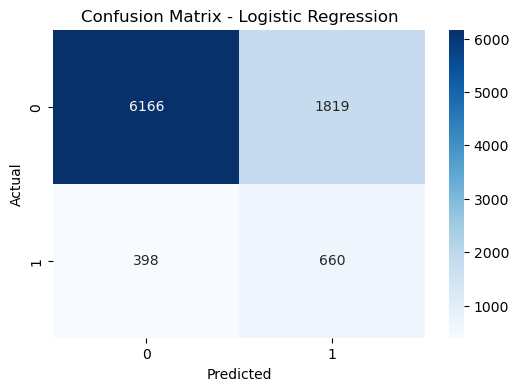

In [70]:
# CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

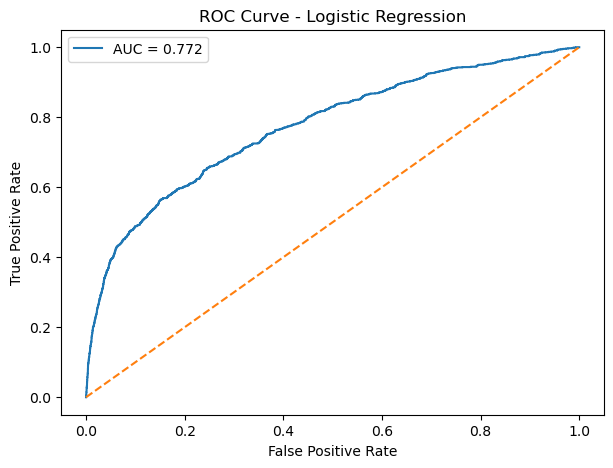

In [71]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.3f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title(
    'ROC Curve - Logistic Regression'
)

plt.legend()

plt.show()

In [72]:
from sklearn.ensemble import RandomForestClassifier

In [73]:
# RANDOM FOREST MODEL

model_rf = Pipeline(
    steps=[
        ('preprocessor', preprocessor),

        (
            'classifier',

            RandomForestClassifier(
                n_estimators=200,
                max_depth=10,
                min_samples_split=10,
                class_weight='balanced',
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# train model
model_rf.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [74]:
# RANDOM FOREST PREDICTION

y_pred_rf = model_rf.predict(X_test)

y_prob_rf = model_rf.predict_proba(
    X_test
)[:,1]


print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.94      0.84      0.89      7985
           1       0.34      0.60      0.43      1058

    accuracy                           0.81      9043
   macro avg       0.64      0.72      0.66      9043
weighted avg       0.87      0.81      0.84      9043



In [77]:
# RANDOM FOREST METRICS

accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)

precision_rf = precision_score(
    y_test,
    y_pred_rf
)

recall_rf = recall_score(
    y_test,
    y_pred_rf
)

f1_rf = f1_score(
    y_test,
    y_pred_rf
)

roc_auc_rf = roc_auc_score(
    y_test,
    y_prob_rf
)

print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_auc_rf:.4f}")

Accuracy : 0.8147
Precision: 0.3370
Recall   : 0.6040
F1 Score : 0.4326
ROC-AUC  : 0.7944


In [76]:
pip install xgboost


   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB 487.6 kB/s eta 0:03:29
   ---------------------------------------- 0.1/101.7 MB 751.6 kB/s eta 0:02:16
   ---------------------------------------- 0.1/101.7 MB 751.6 kB/s eta 0:02:16
   ---------------------------------------- 0.2/101.7 MB 807.1 kB/s eta 0:02:06
   ---------------------------------------- 0.2/101.7 MB 919.0 kB/s eta 0:01:51
   ---------------------------------------- 0.3/101.7 MB 930.9 kB/s eta 0:01:49
   ---------------------------------------- 0.4/101.7 MB 1.0 MB/s eta 0:01:38
   ---------------------------------------- 0.5/101.7 MB 1.1 MB/s eta 0:01:30
   ---------------------------------------- 0.6/101.7 MB 1.2 MB/s eta 0:01:22
   ---------------------------------------- 0.6/101.7 MB 1.3 MB/s eta 0:01:18
   ---------------------------------------- 0.7/101.7 MB 1.3 MB/s

In [80]:
from xgboost import XGBClassifier

In [81]:
# CLASS IMBALANCE RATIO

negative_class = y_train.value_counts()[0]
positive_class = y_train.value_counts()[1]

scale_pos_weight = (
    negative_class /
    positive_class
)

print(scale_pos_weight)

7.548333727251241


In [82]:
# XGBOOST MODEL

model_xgb = Pipeline(
    steps=[
        ('preprocessor', preprocessor),

        (
            'classifier',

            XGBClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=5,
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=scale_pos_weight,
                random_state=42,
                eval_metric='logloss'
            )
        )
    ]
)

# train model
model_xgb.fit(X_train, y_train)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [83]:
# XGBOOST PREDICTION

y_pred_xgb = model_xgb.predict(X_test)

y_prob_xgb = model_xgb.predict_proba(
    X_test
)[:,1]

print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

              precision    recall  f1-score   support

           0       0.95      0.85      0.89      7985
           1       0.36      0.65      0.46      1058

    accuracy                           0.82      9043
   macro avg       0.65      0.75      0.68      9043
weighted avg       0.88      0.82      0.84      9043



In [84]:
# XGBOOST METRICS

accuracy_xgb = accuracy_score(
    y_test,
    y_pred_xgb
)

precision_xgb = precision_score(
    y_test,
    y_pred_xgb
)

recall_xgb = recall_score(
    y_test,
    y_pred_xgb
)

f1_xgb = f1_score(
    y_test,
    y_pred_xgb
)

roc_auc_xgb = roc_auc_score(
    y_test,
    y_prob_xgb
)

print(f"Accuracy : {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall   : {recall_xgb:.4f}")
print(f"F1 Score : {f1_xgb:.4f}")
print(f"ROC-AUC  : {roc_auc_xgb:.4f}")

Accuracy : 0.8222
Precision: 0.3566
Recall   : 0.6465
F1 Score : 0.4597
ROC-AUC  : 0.8057


## Three classification models were evaluated: Logistic Regression, Random Forest, and XGBoost. Among them, XGBoost achieved the best overall performance with the highest F1-score (0.46) and ROC-AUC (0.81), indicating stronger predictive capability for customer subscription behavior.

In [85]:
# GET FEATURE NAMES

encoded_features = model_xgb.named_steps[
    'preprocessor'
].transformers_[1][1].named_steps[
    'encoder'
].get_feature_names_out(
    cat_features
)

all_features = (
    num_features +
    list(encoded_features)
)

print(len(all_features))
print(all_features[:10])

50
['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid']


In [86]:
# FEATURE IMPORTANCE

importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': model_xgb.named_steps[
        'classifier'
    ].feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df.head(20)

,Feature,Importance
48,poutcome_success,0.264684
33,contact_unknown,0.104212
27,housing_no,0.041137
41,month_mar,0.040505
44,month_oct,0.029265
40,month_jun,0.026640
35,month_aug,0.025901
34,month_apr,0.025785
45,month_sep,0.025628
19,marital_married,0.020929


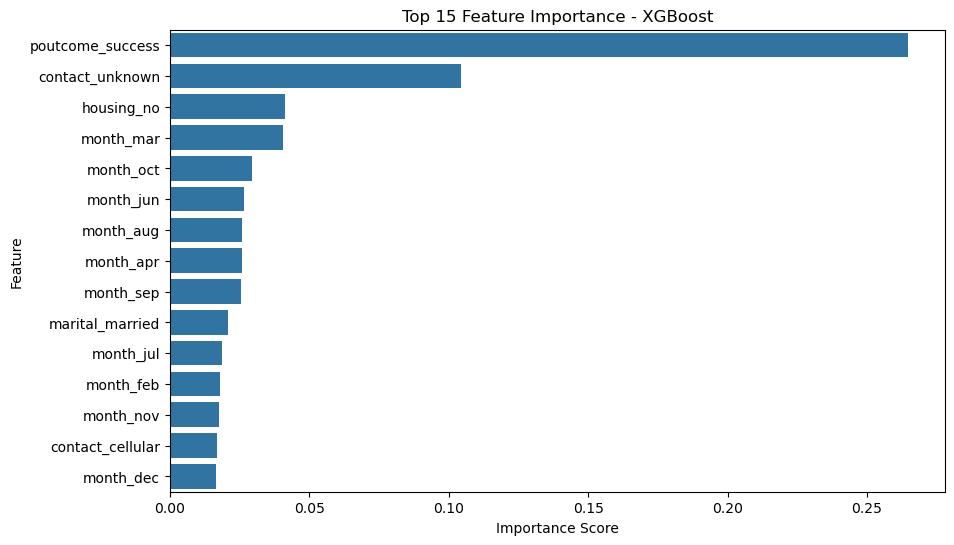

In [87]:
# FEATURE IMPORTANCE PLOT

top_features = importance_df.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title(
    'Top 15 Feature Importance - XGBoost'
)

plt.xlabel('Importance Score')
plt.ylabel('Feature')

plt.show()

In [88]:
# MODEL COMPARISON

comparison_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],

    'Accuracy': [
        accuracy,
        accuracy_rf,
        accuracy_xgb
    ],

    'Precision': [
        precision,
        precision_rf,
        precision_xgb
    ],

    'Recall': [
        recall,
        recall_rf,
        recall_xgb
    ],

    'F1 Score': [
        f1,
        f1_rf,
        f1_xgb
    ],

    'ROC-AUC': [
        roc_auc,
        roc_auc_rf,
        roc_auc_xgb
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.754838,0.266236,0.623819,0.373198,0.772238
1,Random Forest,0.814663,0.337025,0.603970,0.432634,0.794413
2,XGBoost,0.822183,0.356621,0.646503,0.459677,0.805687


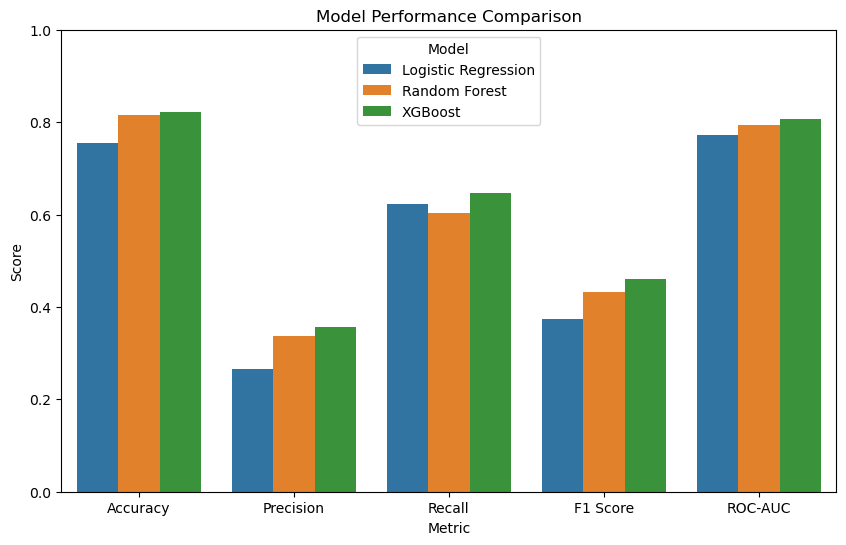

In [89]:
# MODEL PERFORMANCE VISUALIZATION

comparison_melted = comparison_df.melt(
    id_vars='Model',
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=comparison_melted,
    x='Metric',
    y='Score',
    hue='Model'
)

plt.title(
    'Model Performance Comparison'
)

plt.ylim(0,1)

plt.show()

## Business recommendation:
1. Prioritize High-Potential Customers

Based on descriptive analysis and machine learning results, customers with a successful previous campaign outcome (poutcome = success) showed the highest likelihood of subscription. Customers without housing loans and those with higher account balances also demonstrated stronger positive responses.

Recommendation:
The bank should prioritize these customer segments in future campaigns to improve subscription rates and reduce unnecessary marketing costs.

2. Optimize Contact Strategy

The analysis showed that cellular communication performed better than telephone contact in terms of customer response.

Recommendation:
The bank should prioritize mobile (cellular) outreach channels to improve campaign effectiveness and customer engagement.

3. Improve Campaign Timing

Although May had the highest number of contacts, machine learning results suggest that other months (such as March and October) may provide better conversion potential.

Recommendation:
The bank should test campaign performance across different months rather than concentrating efforts only in peak-contact periods.

4. Re-target Previously Successful Customers

Feature importance analysis identified previous successful campaign outcomes as the strongest predictor of subscription.

Recommendation:
Customers who responded positively in previous campaigns should be re-targeted first, as they are significantly more likely to subscribe again.

5. Implement Predictive Targeting Using Machine Learning

Among the evaluated models, XGBoost achieved the best performance:

Accuracy: 82%
Recall: 65%
ROC-AUC: 81%

Recommendation:
The bank can use the predictive model to assign a subscription probability score to customers before contact. High-probability customers should be prioritized for marketing campaigns to improve efficiency and reduce operational costs.

Limitation

The duration feature was excluded from real-time prediction because it becomes available only after the call and may introduce data leakage, which can lead to unrealistic model performance.

